In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch.nn import CrossEntropyLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision.transforms import RandomRotation, RandomHorizontalFlip, ColorJitter

# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define dataset path
dataset_path = "/content/drive/MyDrive/image with free"  # Update this path

Using device: cuda


In [5]:
# Import required libraries
import torchvision.transforms as transforms

# Define augmentations
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Print to verify it works
print("Augmentation pipeline defined successfully!")


Augmentation pipeline defined successfully!


In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from collections import defaultdict

# -------------------------------
# 1. Define Transforms
# -------------------------------

# Transform برای Validation / Test
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Augmentation فقط برای Train
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------------------------------
# 2. Load dataset (initial transform)
# -------------------------------
dataset_path = "/content/drive/MyDrive/image with free"
dataset = datasets.ImageFolder(root=dataset_path, transform=base_transform)

# -------------------------------
# 3. Stratified split
# -------------------------------
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

class_indices = defaultdict(list)

# جمع کردن اندیس‌های هر کلاس
for idx, (_, label) in enumerate(dataset):
    class_indices[label].append(idx)

train_idx, val_idx, test_idx = [], [], []

# تقسیم برای هر کلاس
for cls, indices in class_indices.items():
    np.random.shuffle(indices)
    n_total = len(indices)

    n_test = max(1, int(test_ratio * n_total))
    remaining = n_total - n_test

    n_train = int(train_ratio / (train_ratio + val_ratio) * remaining)
    n_val = remaining - n_train

    train_idx.extend(indices[:n_train])
    val_idx.extend(indices[n_train:n_train + n_val])
    test_idx.extend(indices[n_train + n_val : n_train + n_val + n_test])

# -------------------------------
# 4. Create subsets
# -------------------------------
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# -------------------------------
# 5. Assign transforms separately
# -------------------------------
# فقط Train → augmentation
train_dataset.dataset.transform = train_transform

# Val & Test → بدون augmentation
val_dataset.dataset.transform = base_transform
test_dataset.dataset.transform = base_transform

# -------------------------------
# 6. DataLoaders
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Stratified split + augmentation DONE!")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


🔥 Stratified split + augmentation DONE!
Train samples: 8784
Val samples: 1888
Test samples: 1879


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# Load Pretrained DenseNet161
# ----------------------------
model = models.densenet161(weights=models.DenseNet161_Weights.IMAGENET1K_V1)

# ----------------------------
# Freeze ALL layers first
# ----------------------------
for param in model.parameters():
    param.requires_grad = False

# ----------------------------
# Unfreeze last block (denseblock4 + transition3)
# ----------------------------
for name, module in model.features.named_children():
    if name in ["denseblock4", "transition3"]:
        for param in module.parameters():
            param.requires_grad = True

# ----------------------------
# Replace Classifier
# ----------------------------
num_classes = 10
in_features = model.classifier.in_features

model.classifier = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)

model = model.to(device)

# ----------------------------
# Class Weights
# ----------------------------
class_weights = torch.tensor([1.0, 2.0, 1.5, 0.8, 1.2, 1.8, 1.0, 0.9, 1.3, 2.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ----------------------------
# Optimizer
# ----------------------------
optimizer = optim.Adam([
    {'params': model.features.denseblock4.parameters(), 'lr': 1e-4},
    {'params': model.features.transition3.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

# ----------------------------
# Scheduler (no verbose)
# ----------------------------
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Model and training components are defined successfully.")


Using device: cuda
Model and training components are defined successfully.


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import os

# -----------------------------
# 1. تنظیم دستگاه
# -----------------------------
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. بارگذاری مدل DenseNet161
# -----------------------------
model = models.densenet161(weights="IMAGENET1K_V1")

# فریز کل مدل
for p in model.parameters():
    p.requires_grad = False

# آنفریز denseblock4 و transition3
for name, param in model.features.named_children():
    if name in ["denseblock4", "transition3"]:
        for p in param.parameters():
            p.requires_grad = True

# تغییر classifier برای 10 کلاس
num_classes = 10
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 1024),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)

model = model.to(device)

# -----------------------------
# 3. Loss, Optimizer, Scheduler
# -----------------------------
class_weights = torch.tensor([1,2,1.5,0.8,1.2,1.8,1,0.9,1.3,2.5], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam([
    {'params': model.features.denseblock4.parameters(), 'lr': 1e-4},
    {'params': model.features.transition3.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.1
)

# -----------------------------
# 4. DataLoader بهینه
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=(device.type=='cuda'),
    persistent_workers=(device.type=='cuda')
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type=='cuda'),
    persistent_workers=(device.type=='cuda')
)

# -----------------------------
# 5. Resume از Checkpoint
# -----------------------------
checkpoint_path = "/content/drive/MyDrive/checkpoint_densenet.pth"
start_epoch = 0
best_val_accuracy = 0.0

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_accuracy = checkpoint["best_val_accuracy"]
    print(f"✔ Resumed from epoch = {start_epoch}, best_val_accuracy = {best_val_accuracy:.2f}%")
else:
    print("شروع از صفر (چک‌پوینت پیدا نشد).")

# -----------------------------
# 6. AMP تنظیم شده برای CPU/GPU
# -----------------------------
use_amp = device.type == 'cuda'
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

# -----------------------------
# 7. Training Loop
# -----------------------------
num_epochs = 50

for epoch in range(start_epoch, num_epochs):
    print(f"\n🔵 Epoch {epoch + 1}/{num_epochs}")

    # -------- Training --------
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda', enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = 100 * correct_train / total_train

    # -------- Validation --------
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast(device_type='cuda', enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_acc = 100 * correct_val / total_val
    val_loss /= len(val_loader)

    # Scheduler update
    scheduler.step(val_loss)

    print(f"Train Loss = {train_loss / len(train_loader):.4f}, "
          f"Train Acc = {train_acc:.2f}%, "
          f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.2f}%")

    # -------- Save best model --------
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "best_densenet161_model.pth")
        print("🌟 Best model updated!")

    # -------- Save checkpoint هر epoch --------
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_accuracy": best_val_accuracy
    }, checkpoint_path)
    print("💾 Checkpoint saved.")


Using device: cuda
شروع از صفر (چک‌پوینت پیدا نشد).

🔵 Epoch 1/50


/tmp/ipython-input-2598563733.py:102: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Train Loss = 0.4216, Train Acc = 85.77%, Val Loss = 0.2485, Val Acc = 92.53%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 2/50
Train Loss = 0.1671, Train Acc = 94.00%, Val Loss = 0.2353, Val Acc = 93.43%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 3/50
Train Loss = 0.1056, Train Acc = 96.24%, Val Loss = 0.2486, Val Acc = 93.43%
💾 Checkpoint saved.

🔵 Epoch 4/50
Train Loss = 0.0733, Train Acc = 97.15%, Val Loss = 0.2184, Val Acc = 94.49%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 5/50
Train Loss = 0.0500, Train Acc = 98.28%, Val Loss = 0.2132, Val Acc = 94.39%
💾 Checkpoint saved.

🔵 Epoch 6/50
Train Loss = 0.0384, Train Acc = 98.71%, Val Loss = 0.2761, Val Acc = 93.43%
💾 Checkpoint saved.

🔵 Epoch 7/50
Train Loss = 0.0399, Train Acc = 98.69%, Val Loss = 0.3101, Val Acc = 93.33%
💾 Checkpoint saved.

🔵 Epoch 8/50
Train Loss = 0.0285, Train Acc = 98.96%, Val Loss = 0.2667, Val Acc = 93.70%
💾 Checkpoint saved.

🔵 Epoch 9/50
Train Loss = 0.0154, Train Acc = 99.40%, Val L

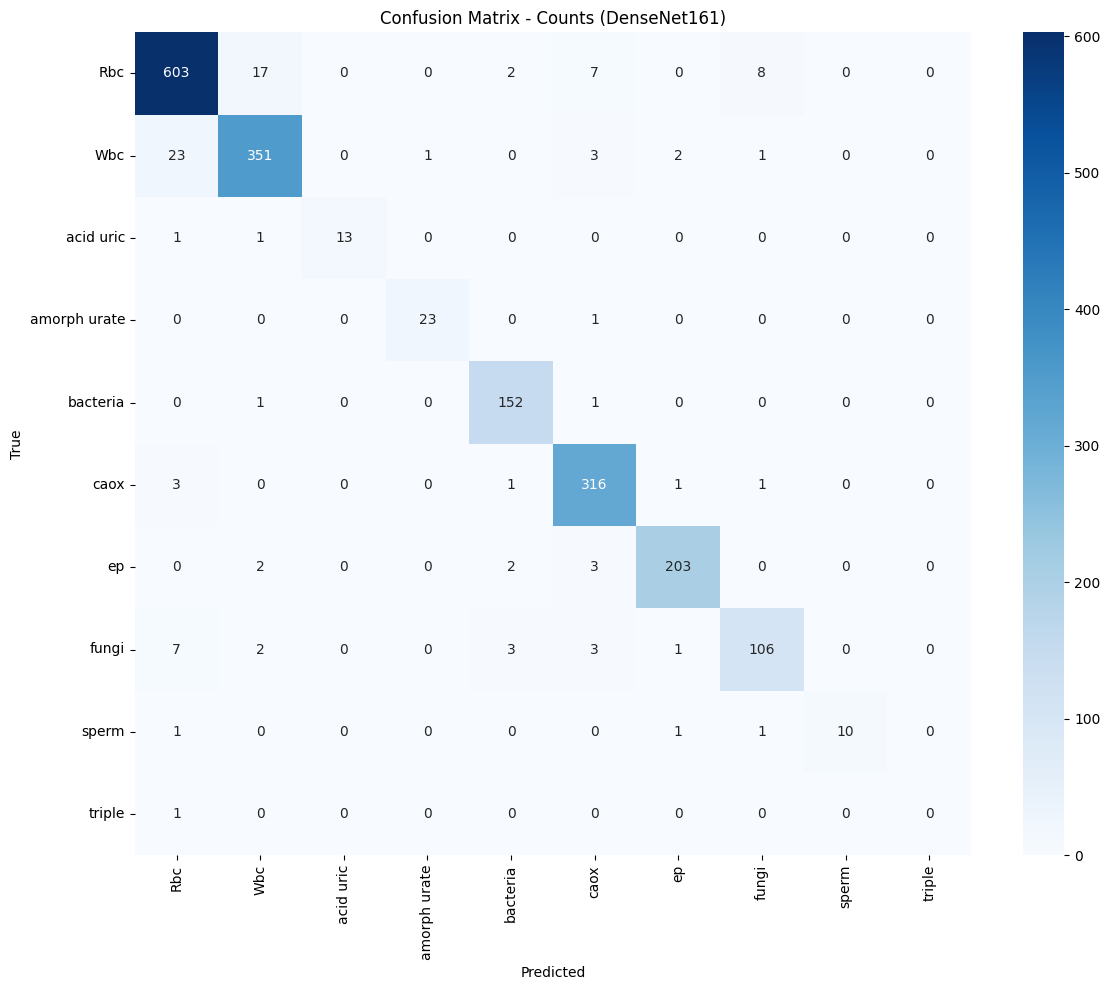

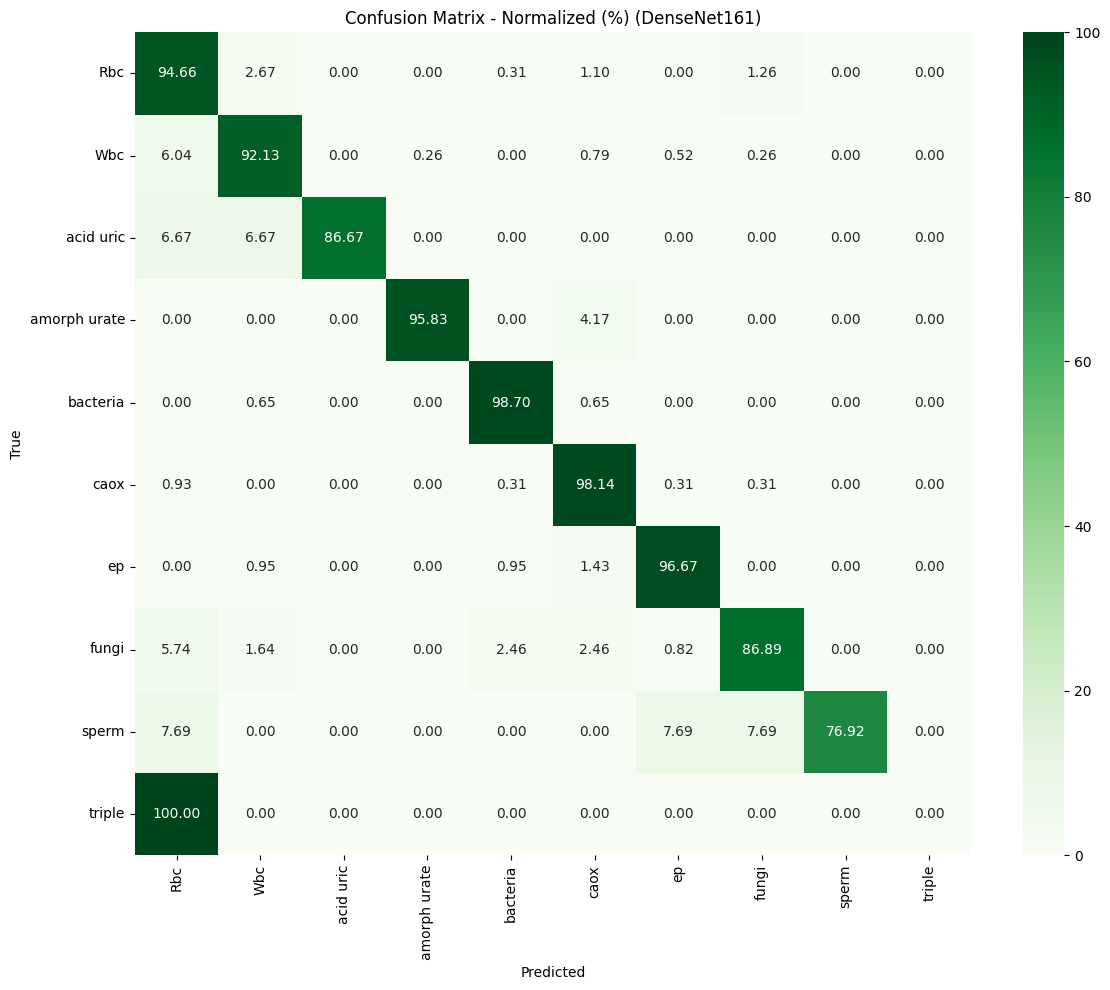


====================== CLASSIFICATION REPORT ======================

              precision    recall  f1-score   support

         Rbc     0.9437    0.9466    0.9451       637
         Wbc     0.9385    0.9213    0.9298       381
   acid uric     1.0000    0.8667    0.9286        15
amorph urate     0.9583    0.9583    0.9583        24
    bacteria     0.9500    0.9870    0.9682       154
        caox     0.9461    0.9814    0.9634       322
          ep     0.9760    0.9667    0.9713       210
       fungi     0.9060    0.8689    0.8870       122
       sperm     1.0000    0.7692    0.8696        13
      triple     0.0000    0.0000    0.0000         1

    accuracy                         0.9457      1879
   macro avg     0.8619    0.8266    0.8421      1879
weighted avg     0.9452    0.9457    0.9452      1879


📁 فایل‌ها ذخیره شدند در: /content/drive/MyDrive/results_cm_densenet


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os

# -----------------------------
# کلاس‌ها (به ترتیب ImageFolder)
# -----------------------------
class_names = ['Rbc', 'Wbc', 'acid uric', 'amorph urate', 'bacteria',
               'caox', 'ep', 'fungi', 'sperm', 'triple']

# مسیر ذخیره نتایج
save_dir = "/content/drive/MyDrive/results_cm_densenet"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# پیش‌بینی روی دیتاست تست
# -----------------------------
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

# Normalized Confusion Matrix (درصدی)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, None]
cm_percent = np.nan_to_num(cm_percent) * 100  # تبدیل به درصد

# -----------------------------
#  رسم و ذخیره CM خام
# -----------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Counts (DenseNet161)")
plt.tight_layout()
plt.savefig(f"{save_dir}/CM_counts.png", dpi=300)
plt.show()

# -----------------------------
#  رسم و ذخیره CM نرمال‌شده
# -----------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Normalized (%) (DenseNet161)")
plt.tight_layout()
plt.savefig(f"{save_dir}/CM_normalized.png", dpi=300)
plt.show()

# -----------------------------
#  Classification Report
# -----------------------------
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n====================== CLASSIFICATION REPORT ======================\n")
print(report)

# ذخیره گزارش
with open(f"{save_dir}/classification_report.txt", "w") as f:
    f.write(report)

print(f"\n📁 فایل‌ها ذخیره شدند در: {save_dir}")


In [10]:
# Evaluate the model on the test set
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_test += (predicted == labels).sum().item()
        total_test += labels.size(0)

test_loss /= total_test
test_accuracy = 100 * correct_test / total_test
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

torch.save(model.state_dict(), "best_model_test.pth")
print("Model saved successfully!")


Test Loss: 0.2502, Test Accuracy: 94.57%
Model saved successfully!


In [11]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

def evaluate_model_performance(model, test_loader, classes):
    model.eval()
    y_true = []
    y_pred = []
    start_time = time.time()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # زمان پایان
    end_time = time.time()
    calculation_time = end_time - start_time

    # محاسبه معیارها
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # نمایش نتایج
    print("Evaluation Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Calculation Time: {calculation_time:.2f} seconds")



    return accuracy, precision, recall, f1, calculation_time

# فراخوانی تابع برای ارزیابی
classes = ["'Rbc', 'Wbc', 'acid uric', 'amorph urate', 'bacteria', 'caox', 'ep', 'fungi', 'sperm', 'triple'"]  # اسامی کلاس‌ها را اینجا قرار دهید
evaluate_model_performance(model, test_loader, classes)



Evaluation Results:
Accuracy: 0.9457
Precision: 0.9452
Recall (Sensitivity): 0.9457
F1-Score: 0.9452
Calculation Time: 12.99 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.9457158062799361,
 0.9452425433563488,
 0.9457158062799361,
 0.9452080902122252,
 12.992031574249268)

مدل با موفقیت بارگذاری شد.


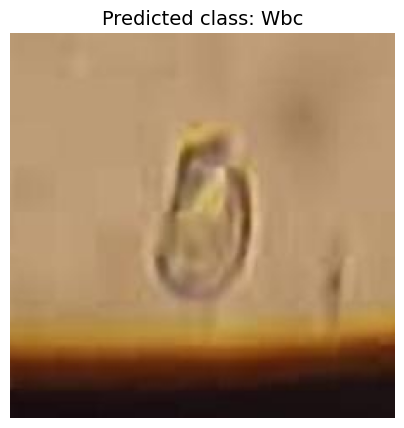

Predicted index: 1
Predicted class: Wbc


In [12]:
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1) تعریف مدل مطابق وزن‌های ذخیره‌شده
# --------------------------------------------------
class Net(nn.Module):
    def __init__(self, num_classes=10):
        super(Net, self).__init__()

        # مدل ResNet50 بدون وزن pretrained
        self.resnet = models.resnet50(weights=None)

        # جایگزینی لایه FC اصلی با معماری دلخواه
        self.resnet.fc = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

# --------------------------------------------------
# 2) بارگذاری مدل و state_dict با strict=False
# --------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Net(num_classes=10).to(device)

model_path = "/content/drive/MyDrive/best_resnet50_model.pth"
state_dict = torch.load(model_path, map_location=device)

# اضافه کردن prefix 'resnet.' به کلیدها برای تطابق با مدل
new_state_dict = {}
for k, v in state_dict.items():
    new_state_dict['resnet.' + k] = v

# strict=False برای جلوگیری از ارور missing running_mean/running_var
model.load_state_dict(new_state_dict, strict=False)
model.eval()
print("مدل با موفقیت بارگذاری شد.")

# --------------------------------------------------
# 3) نام کلاس‌ها
# --------------------------------------------------
class_names = [
    'Rbc', 'Wbc', 'acid uric', 'amorph urate',
    'bacteria', 'caox', 'ep', 'fungi', 'sperm', 'triple'
]

# --------------------------------------------------
# 4) تابع پیش‌بینی تصویر همراه با نمایش عکس
# --------------------------------------------------
def predict_and_show_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    img = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_name = class_names[pred_idx]

    # نمایش تصویر همراه با نام کلاس پیش‌بینی‌شده
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted class: {pred_name}", fontsize=14)
    plt.show()

    return pred_idx, pred_name

# --------------------------------------------------
# 5) اجرای تست
# --------------------------------------------------
test_image = "/content/drive/MyDrive/image of urine for test/Wbc21_Wbc_255_928_superres.jpg"  
pred_idx, pred_name = predict_and_show_image(test_image)

print("Predicted index:", pred_idx)
print("Predicted class:", pred_name)
